Fetched 1359 papers from SPARQL
Finished querying graph! Total unique papers found: 1228

Result: machine_learning, random_forest -> 2010: 5, 2011: 4, 2012: 10, 2013: 18, 2014: 15, 2015: 20, 2016: 32, 2017: 45, 2018: 81, 2019: 136, 2020: 214, 2021: 322, 2022: 285, 2023: 1


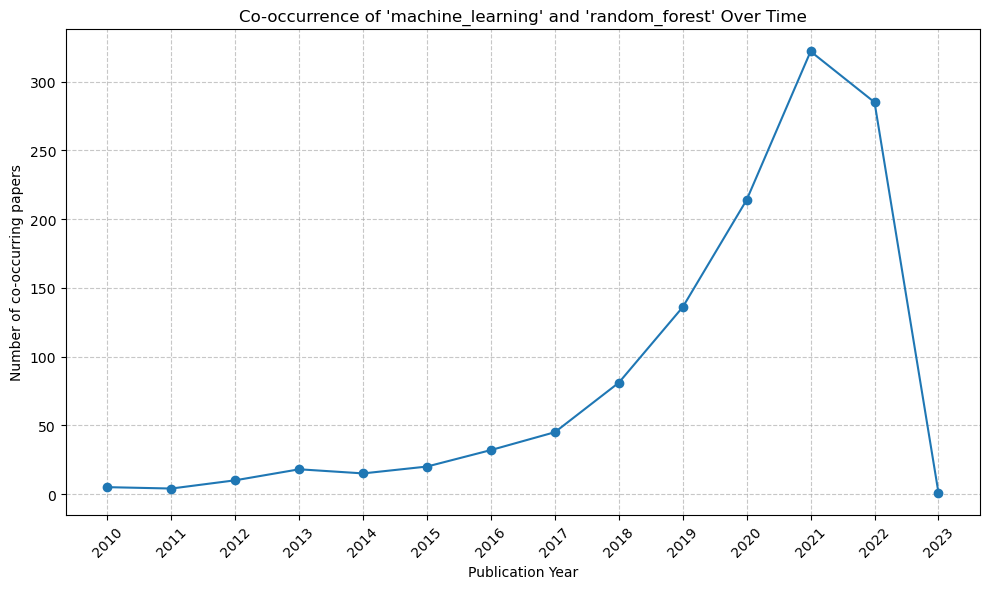

In [1]:
import requests
import urllib3
import time
import matplotlib.pyplot as plt
from collections import Counter

urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

def get_shared_paper_ids_from_cskg(entity1, entity2):
    endpoint_url = "https://192.167.149.12:9001/sparql/"

    # This loop keeps running until the database runs out of papers, or the timeout will appear.
    sparql_query = f"""
        PREFIX rdf:  <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
        PREFIX cskg: <https://w3id.org/cskg/resource/>
        PREFIX provo: <http://www.w3.org/ns/prov#>

        SELECT ?paperID
        FROM <https://w3id.org/cskg>
        WHERE {{
            ?statement rdf:subject ?subject ;
            rdf:predicate ?predicate ;
            rdf:object ?object ;
            provo:wasDerivedFrom ?paperID .
 
            VALUES ?subject {{ cskg:{entity1} cskg:{entity2} }}
            VALUES ?object {{ cskg:{entity1} cskg:{entity2} }}
        }}
        """

    try:
        response = requests.post(
                endpoint_url, # the distination of the request.
                data={"query": sparql_query},
                headers={"Accept": "application/sparql-results+json"},
                verify=False,
                timeout=60 # Gives the proxy 60 seconds before it gives up
        )
        response.raise_for_status() # It will check if the server respond other than 200, it will give an error.
            
            # It will get the data inside the "bindings".
        bindings = response.json().get("results", {}).get("bindings", [])
            
            # If the database returns 0 results, we reached the end! Break the loop.
                
        batch_ids = []
        for binding in bindings:
            paper_uri = binding["paperID"]["value"]
            paper_id = paper_uri.split("/")[-1] # It will take the last peice after the last '/'.
                # every paper ID start with "W", this will check if it start with "W" or not, if it doesn't that mean it is fake ID.
            if paper_id.startswith("W"):
                batch_ids.append(paper_id)
                    
            # Add this batch to our master list
        print(f"Fetched {len(bindings)} papers from SPARQL")
                  
    except Exception as e:
        print(f"Failed SPARQL query: {e}")

    # Deduplicate the final massive list of IDs
    unique_ids = list(set(batch_ids))
    print(f"Finished querying graph! Total unique papers found: {len(unique_ids)}")
    return unique_ids

def get_years_from_openalex(paper_ids):
    years = []
    headers = {"User-Agent": "hamza.jbn123@gmail.com"}
    batch_size = 100

    # It make them all the ids in batches so it will not make it heavy to the computer.
    for i in range(0, len(paper_ids), batch_size):
        batch = paper_ids[i:i + batch_size]
        id_filter = "|".join(batch)
        # "per_page=100": It will make sure that we will get 100 papers only.
# We may need the id later that why we ask for it "select=id" the result: [{"id": "W456", "year": 2018}, {"id": "W123", "year": 2021}...]
        url = f"https://api.openalex.org/works?filter=ids.openalex:{id_filter}&select=id,publication_year&per_page=100"
        
        try:
            r = requests.get(url, headers=headers, timeout=30)
            r.raise_for_status() # this line will stop the code if an error happen.
            data = r.json()
            for work in data.get('results', []): 
                year = work.get('publication_year') # It will get inside the paper and get the year.
                if year:
                    years.append(year)
        except Exception as e:
            print(f"Failed batch lookup: {e}")

        time.sleep(0.1)

    return years

# Count how many papers per year, then sort them by year.
def create_distribution(years):
    return dict(sorted(Counter(years).items()))

def plot_distribution(distribution, entity1, entity2):
    if not distribution:
        print("No data to plot!")
        return

    years = list(distribution.keys()) # Grabs just the years (2018, 2019, 2020) and makes them X-axis.
    counts = list(distribution.values()) # Grabs just the numbers of papers (1, 5, 12) and makes them Y-axis.

    plt.figure(figsize=(10, 6))
    plt.plot(years, counts, marker='o', linestyle='-')
    plt.title(f"Co-occurrence of '{entity1}' and '{entity2}' Over Time")
    plt.xlabel("Publication Year")
    plt.ylabel("Number of co-occurring papers")
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.xticks(years, rotation=45)
    plt.tight_layout()
    plt.show()

entity_A = "machine_learning"
entity_B = "random_forest"

ids = get_shared_paper_ids_from_cskg(entity_A, entity_B)
    
years = get_years_from_openalex(ids)
distribution = create_distribution(years)

print(f"\nResult: {entity_A}, {entity_B} -> " +
          ", ".join([f"{year}: {count}" for year, count in distribution.items()]))
    
plot_distribution(distribution, entity_A, entity_B)
